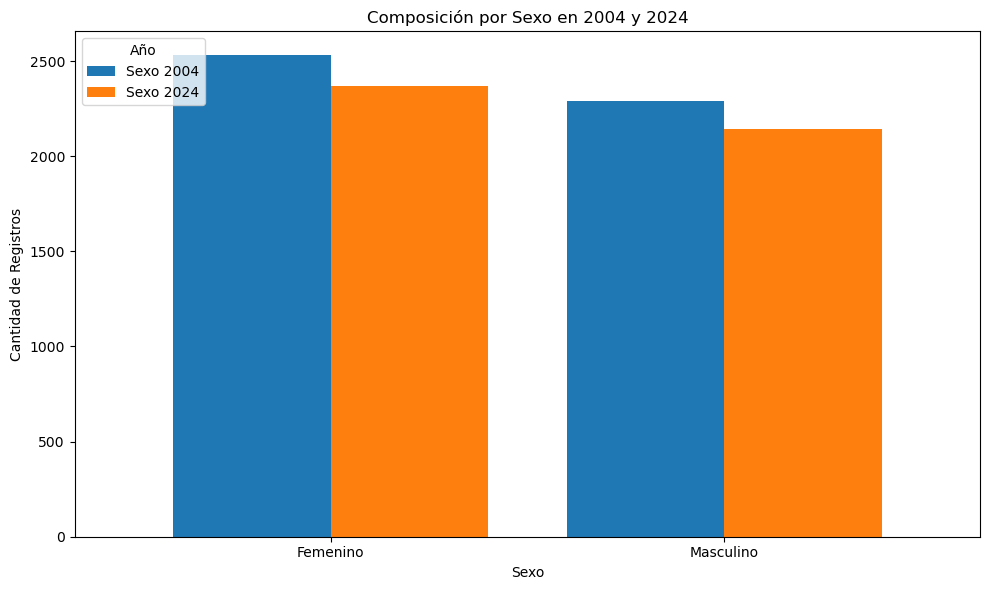

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar los datos de 2004 y 2024
base_2004 = pd.read_stata("C:/Users/CRIS/Documents/Big Data/Big Data Grupo 19/TP2/Individual_t104.dta")
base_2024 = pd.read_excel("C:/Users/CRIS/Documents/Big Data/Big Data Grupo 19/TP2/usu_individual_T124.xlsx")

# Filtrar por la región 42
base_2004 = base_2004[base_2004['region'] == "Cuyo"]
base_2024 = base_2024[base_2024["REGION"] == 42]

# Renombrar columnas en 2004 para que coincidan con las de 2024
renombrar_columnas_2004 = {
    'ch03': 'CH03',
    'ch04': 'CH04',
    'ch06': 'CH06',
    'ch07': 'CH07',
    'estado': 'ESTADO',
    'cat_ocup': 'CAT_OCUP',
    'pp3e_tot': 'PP3E_TOT',
    'p21': 'P21',
    'pp07h': 'PP07H',
    'nivel_ed': 'NIVEL_ED',
    'pp04b_cod': 'PP04B_COD',
    'pp04d_cod': 'PP04D_COD',
    'ch08': 'CH08',
    'pp07g2': 'PP07G2',
    'pp07g3': 'PP07G3',
    'cat_inac': 'CAT_INAC',
}
base_2004.rename(columns=renombrar_columnas_2004, inplace=True)


# Agregar columna 'año'
base_2004["año"] = 2004
base_2024["año"] = 2024

# Comprobar los valores únicos en 'CH04' para asegurar que el sexo está bien codificado
#print(base_2004['CH04'].unique())  # Se puede verificar los valores únicos en 'CH04' de 2004 borrando el "#"

# Si los valores están numéricamente codificados, reemplazarlos
#Utilicé "cat.rename_categories" en vez de "replace" en base_2004 ya que no estaban en valores numéricos
base_2004['CH04'] = base_2004['CH04'].cat.rename_categories({"Varón": 'Masculino', "Mujer": 'Femenino'})
base_2024['CH04'] = base_2024['CH04'].replace({1: 'Masculino', 2: 'Femenino'})

# Verificar los valores después del reemplazo (Verificar eliminando "#")
#print(base_2004['CH04'].unique())

# Contar la cantidad de registros para cada sexo en 2004 y 2024
sexo_2004 = base_2004['CH04'].value_counts()
sexo_2024 = base_2024['CH04'].value_counts()

# Convertir a un DataFrame para graficar
df_sexo = pd.DataFrame({
    'Sexo 2004': sexo_2004,
    'Sexo 2024': sexo_2024
}).fillna(0)  # Para manejar cualquier valor nulo si no hay registros en 2024 o 2004

# Graficar la composición por sexo
df_sexo.plot(kind='bar', figsize=(10,6), width=0.8)

# Agregar etiquetas y título
plt.title('Composición por Sexo en 2004 y 2024')
plt.xlabel('Sexo')
plt.ylabel('Cantidad de Registros')
plt.xticks(rotation=0)
plt.legend(title='Año', loc='upper left')

# Mostrar gráfico
plt.tight_layout()
plt.show()


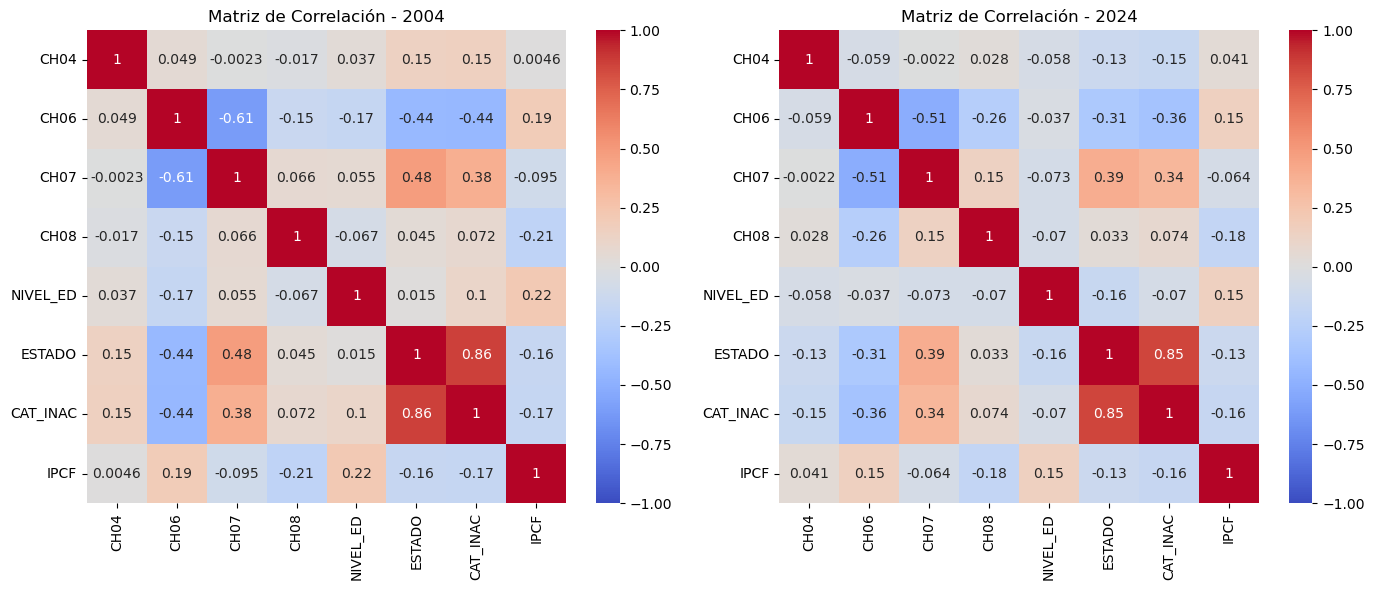

In [4]:
import seaborn as sns

# Variables seleccionadas
variables = ['CH04', 'CH06', 'CH07', 'CH08', 'NIVEL_ED', 'ESTADO', 'CAT_INAC', 'IPCF']
base_2004.rename(columns={'ipcf': 'IPCF'}, inplace=True)
# Función para preparar y codificar los datos
def preparar_datos(df, variables):
    df_seleccion = df[variables].copy()
    
    # Convertir variables categóricas a numéricas
    for col in df_seleccion.columns:
        if df_seleccion[col].dtype.name == 'category' or df_seleccion[col].dtype == 'object':
            df_seleccion[col] = pd.Categorical(df_seleccion[col]).codes
    return df_seleccion

# Preparar los datos
datos_2004 = preparar_datos(base_2004, variables)
datos_2024 = preparar_datos(base_2024, variables)

# Calcular matrices de correlación
corr_2004 = datos_2004.corr()
corr_2024 = datos_2024.corr()

# Visualizar matrices con heatmaps
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.heatmap(corr_2004, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlación - 2004')

plt.subplot(1, 2, 2)
sns.heatmap(corr_2024, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlación - 2024')

plt.tight_layout()
plt.show()

In [6]:
# Filtrar solo los desocupados (ESTADO == 2)
base_2004_desocupados = base_2004[base_2004['ESTADO'] == "Desocupado"]
base_2024_desocupados = base_2024[base_2024['ESTADO'] == 2]

# Filtrar solo los inacvitos (ESTADO == 3)
base_2004_inactivos = base_2004[base_2004['ESTADO'] == "Inactivo"]
base_2024_inactivos = base_2024[base_2024['ESTADO'] == 3]

# Filtrar solo los ocupados (ESTADO == 1)
base_2004_ocupados = base_2004[base_2004['ESTADO'] == "Ocupado"]
base_2024_ocupados = base_2024[base_2024['ESTADO'] == 1]

#Creo una variable para dar un valor numérico a la cantidad que hay en las columnas
desocupados2004 = base_2004_desocupados["ESTADO"].count()
inactivos2004 = base_2004_inactivos["ESTADO"].count()
desocupados2024 = base_2024_desocupados["ESTADO"].count()
inactivos2024 = base_2024_inactivos["ESTADO"].count()


import numpy as np
#Definimos la media de los ocupados, desocupados e inactivos del 2004 y 2024 por separado
base_2004_ocupados_respuesta = base_2004_ocupados["IPCF"]
media_ocupados2004 = np.mean(base_2004_ocupados_respuesta)

base_2004_desocupados_respuesta = base_2004_desocupados["IPCF"]
media_desocupados2004 = np.mean(base_2004_desocupados_respuesta)

base_2004_inactivos_respuesta = base_2004_inactivos["IPCF"] 
media_inactivos2004 = np.mean(base_2004_inactivos_respuesta)

base_2024_ocupados_respuesta = base_2024_ocupados["IPCF"]
media_ocupados2024 = np.mean(base_2024_ocupados_respuesta)

base_2024_desocupados_respuesta = base_2024_desocupados["IPCF"]
media_desocupados2024 = np.mean(base_2024_desocupados_respuesta)

base_2024_inactivos_respuesta = base_2024_inactivos["IPCF"]
media_inactivos2024 = np.mean(base_2024_inactivos_respuesta)

#Como pide la parte III, aquí se hayan las respuestas de la pregunta 5 
print("Los desocupados en 2004 son:", desocupados2004)
print("Los inactivos en 2004 son:", inactivos2004)
print("Los desocupados en 2024 son:", desocupados2024)
print("Los inactivos en 2024 son:", inactivos2024)
print("La media de los ocupados en 2004 son:", media_ocupados2004)
print("La media de los desocupados en 2004 son:", media_desocupados2004)
print("La media de los inactivos en 2004 son:", media_inactivos2004)
print("La media de los ocupados en 2024 son:", media_ocupados2024)
print("La media de los desocupados en 2024 son:", media_desocupados2024)
print("La media de los inactivos en 2024 son:", media_inactivos2024)


Los desocupados en 2004 son: 223
Los inactivos en 2004 son: 1881
Los desocupados en 2024 son: 100
Los inactivos en 2024 son: 1816
La media de los ocupados en 2004 son: 334.83064163915503
La media de los desocupados en 2004 son: 173.56871597510613
La media de los inactivos en 2004 son: 256.5620696304109
La media de los ocupados en 2024 son: 187663.44854311197
La media de los desocupados en 2024 son: 107609.0052
La media de los inactivos en 2024 son: 148808.20412444937


In [8]:
# Filtrar base 2024
# Ver cuántas personas no respondieron su condición de actividad (ESTADO = 0)
# Guardar las personas que sí respondieron (ESTADO distinto de 0)
no_respondieron_2024 = base_2024[base_2024['ESTADO'] == 0]
respondieron_2024 = base_2024[base_2024['ESTADO'] != 0]

print("2024:")
print(f" - No respondieron: {no_respondieron_2024.shape[0]}")
print(f" - Respondieron: {respondieron_2024.shape[0]}")

2024:
 - No respondieron: 6
 - Respondieron: 4507


In [10]:
# Filtrar base 2004
# Ver cuántas personas no respondieron su condición de actividad (ESTADO = 0)
# Guardar las personas que sí respondieron (ESTADO distinto de 0)
no_respondieron_2004 = base_2004[base_2004['ESTADO'] == 0]
respondieron_2004 = base_2004[base_2004['ESTADO'] != 0]

print("2004:")
print(f" - No respondieron: {no_respondieron_2004.shape[0]}")
print(f" - Respondieron: {respondieron_2004.shape[0]}\n")

2004:
 - No respondieron: 0
 - Respondieron: 4821



In [12]:
# Guardamos tanto los que respondieron como los que no
respondieron_2004.to_csv("respondieron_2004.csv", index=False)
no_respondieron_2004.to_csv("no_respondieron_2004.csv", index=False)

respondieron_2024.to_csv("respondieron_2024.csv", index=False)
no_respondieron_2024.to_csv("no_respondieron_2024.csv", index=False)


In [24]:
#Creamos la comumna "PEA" para el año 2004 que es el faltante
respondieron_2004["PEA"] = np.where(respondieron_2004["ESTADO"].isin(["Ocupado", "Desocupado"]), 1, 0)


In [26]:
# Porcentajes de PEA y No PEA en cada año
porcentaje_2004 = respondieron_2004['PEA'].value_counts(normalize=True).sort_index() * 100
porcentaje_2024 = respondieron_2024['PEA'].value_counts(normalize=True).sort_index() * 100

# Aseguramos que estén ambos valores: 0 (No PEA) y 1 (PEA)
porcentaje_2004 = porcentaje_2004.reindex([0, 1], fill_value=0)
porcentaje_2024 = porcentaje_2024.reindex([0, 1], fill_value=0)


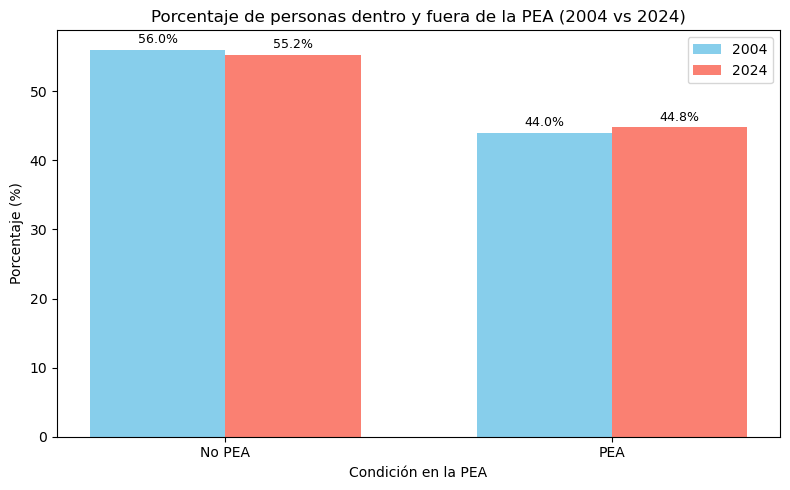

In [28]:
import matplotlib.pyplot as plt

# Labels y valores
labels = ['No PEA', 'PEA']
valores_2004 = porcentaje_2004.values
valores_2024 = porcentaje_2024.values

x = range(len(labels))
bar_width = 0.35

# Crear gráfico
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar([i - bar_width/2 for i in x], valores_2004, width=bar_width, label='2004', color='skyblue')
ax.bar([i + bar_width/2 for i in x], valores_2024, width=bar_width, label='2024', color='salmon')

# Etiquetas y estilo
ax.set_xlabel('Condición en la PEA')
ax.set_ylabel('Porcentaje (%)')
ax.set_title('Porcentaje de personas dentro y fuera de la PEA (2004 vs 2024)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Mostrar los valores arriba de cada barra
for i in x:
    ax.text(i - bar_width/2, valores_2004[i] + 1, f"{valores_2004[i]:.1f}%", ha='center', fontsize=9)
    ax.text(i + bar_width/2, valores_2024[i] + 1, f"{valores_2024[i]:.1f}%", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Este gráfico compara, en términos porcentuales, la proporción de personas que forman parte de la Población Económicamente Activa (PEA) en los años 2004 y 2024.
# PEA (valor 1): personas que están ocupadas o desocupadas activamente buscando trabajo. 
# No PEA (valor 0): personas inactivas (no trabajan ni buscan trabajo, por ejemplo: estudiantes, jubilados, amas de casa).
# Si en 2024 hay un mayor porcentaje en la PEA que en 2004, significa que aumentó la participación laboral.
# Si disminuyó la PEA puede haber un aumento de inactividad, jubilaciones, desánimo económico, etc.

In [34]:
#Con este paso eliminamos los valores de "NaN"
respondieron_2004["CH06"] = respondieron_2004["CH06"].dropna()

In [44]:
#Ahora lo pasamos a números enteros
respondieron_2004["CH06"] = pd.to_numeric(respondieron_2004["CH06"], errors="coerce")

In [48]:
# CH06 (edad) viene como texto enves de numero por lo que lo convertimos en valor numerico
respondieron_2024.loc[:, 'CH06'] = pd.to_numeric(respondieron_2024['CH06'], errors='coerce')
respondieron_2004.loc[:, 'CH06'] = pd.to_numeric(respondieron_2004['CH06'], errors='coerce')

# Crear la columna PET
respondieron_2024.loc[:, 'PET'] = respondieron_2024['CH06'].apply(lambda x: 1 if 15 <= x <= 65 else 0)
respondieron_2004.loc[:, 'PET'] = respondieron_2004['CH06'].apply(lambda x: 1 if 15 <= x <= 65 else 0)

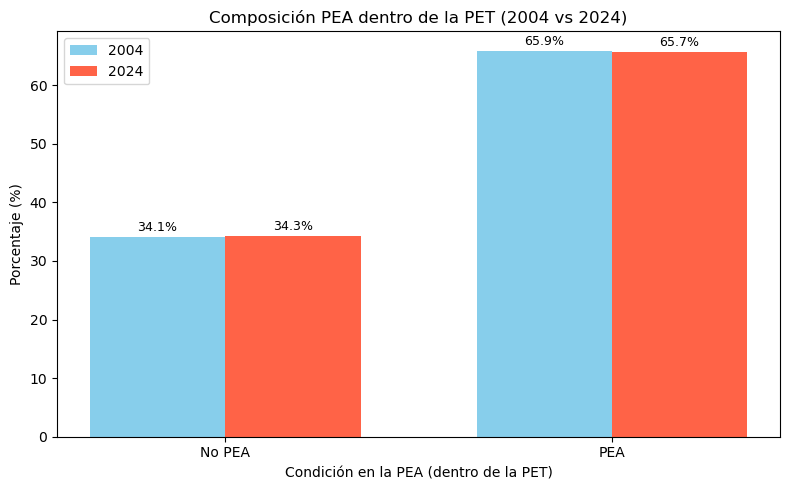

In [50]:
import matplotlib.pyplot as plt

# Filtrar solo PET
pet_2004 = respondieron_2004[respondieron_2004['PET'] == 1]
pet_2024 = respondieron_2024[respondieron_2024['PET'] == 1]

# Porcentaje de PEA dentro de PET
pea_2004 = pet_2004['PEA'].value_counts(normalize=True).sort_index() * 100
pea_2024 = pet_2024['PEA'].value_counts(normalize=True).sort_index() * 100

# Asegurar 0 y 1
pea_2004 = pea_2004.reindex([0, 1], fill_value=0)
pea_2024 = pea_2024.reindex([0, 1], fill_value=0)

# Datos para gráfico
labels = ['No PEA', 'PEA']
valores_2004 = pea_2004.values
valores_2024 = pea_2024.values
x = range(len(labels))
bar_width = 0.35

# Gráfico
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar([i - bar_width/2 for i in x], valores_2004, width=bar_width, label='2004', color='skyblue')
ax.bar([i + bar_width/2 for i in x], valores_2024, width=bar_width, label='2024', color='tomato')

ax.set_xlabel('Condición en la PEA (dentro de la PET)')
ax.set_ylabel('Porcentaje (%)')
ax.set_title('Composición PEA dentro de la PET (2004 vs 2024)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Mostrar los valores
for i in x:
    ax.text(i - bar_width/2, valores_2004[i] + 1, f"{valores_2004[i]:.1f}%", ha='center', fontsize=9)
    ax.text(i + bar_width/2, valores_2024[i] + 1, f"{valores_2024[i]:.1f}%", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Este gráfico muestra qué proporción de la población en edad de trabajar (15-65 años) está económicamente activa (PEA) y cuál no.
# La diferencia entre PET y PEA representa a las personas que no trabajan ni buscan trabajo, a pesar de estar en edad laboral (como estudiantes, amas de casa, personas desalentadas, etc.).
# 

In [52]:
# Crear la columna 'desocupado' (1 si ESTADO == 2, 0 en otro caso)
# ESTADO == 2 representa a los desocupados
# ESTADO == 1 a los ocupados
respondieron_2004 = respondieron_2004.copy()
respondieron_2024 = respondieron_2024.copy()

respondieron_2004["Desocupado"] = np.where(respondieron_2004["ESTADO"] == "Desocupado", 1, 0)
respondieron_2024['Desocupado'] = respondieron_2024['ESTADO'].apply(lambda x: 1 if x == 2 else 0)

# Contar cantidad de desocupados
desocupados_2004 = respondieron_2004['Desocupado'].sum()
desocupados_2024 = respondieron_2024['Desocupado'].sum()

print(f"Desocupados en 2004: {desocupados_2004}")
print(f"Desocupados en 2024: {desocupados_2024}")


Desocupados en 2004: 223
Desocupados en 2024: 100


In [54]:
#Previo a agrupar y calcular la proporción de "Desocupados", ordenamos las respuestas de "NIVEL_ED" del 2004
respondieron_2004["NIVEL_ED"] = respondieron_2004["NIVEL_ED"].map({
    'Primaria Completa': 1,
    'Primaria Incompleta (incluye educación especial)': 2,
    'Secundaria Completa': 3,
    'Secundaria Incompleta': 4,
    'Sin instrucción': 5,
    'Superior Universitaria Completa': 6,
    'Superior Universitaria Incompleta': 7,
    })
# Agrupamos y calculamos proporciones de desocupados
desocupacion_educ_2004 = (
    respondieron_2004.groupby('NIVEL_ED', observed=True)['Desocupado']
    .mean()
    .reset_index()
    .rename(columns={'Desocupado': 'Proporción_2004'})
)

desocupacion_educ_2024 = (
    respondieron_2024.groupby('NIVEL_ED', observed=True)['Desocupado']
    .mean()
    .reset_index()
    .rename(columns={'Desocupado': 'Proporción_2024'})
)


In [56]:
comparacion = pd.merge(desocupacion_educ_2004, desocupacion_educ_2024, on='NIVEL_ED', how='outer')


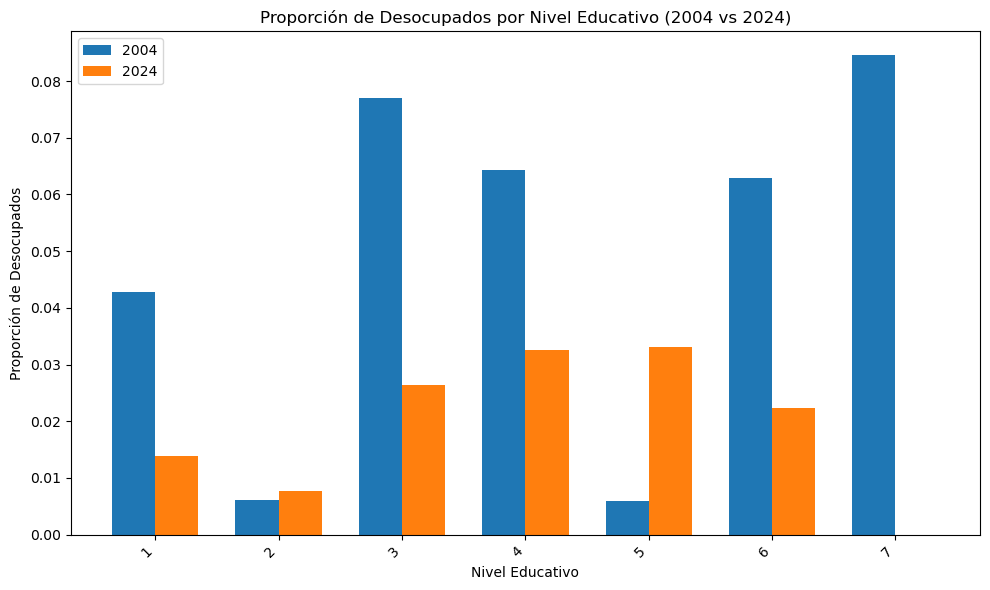

In [58]:
import matplotlib.pyplot as plt
import numpy as np

niveles = comparacion['NIVEL_ED']
x = np.arange(len(niveles))  # posiciones
width = 0.35  # ancho de barras

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, comparacion['Proporción_2004'], width, label='2004')
bars2 = ax.bar(x + width/2, comparacion['Proporción_2024'], width, label='2024')

# Agregar etiquetas y leyenda
ax.set_xlabel('Nivel Educativo')
ax.set_ylabel('Proporción de Desocupados')
ax.set_title('Proporción de Desocupados por Nivel Educativo (2004 vs 2024)')
ax.set_xticks(x)
ax.set_xticklabels(niveles, rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.show()

In [74]:
niveles_2004 = [str(nivel) for nivel in desocupacion_educ_2004.index]
niveles_2024 = [str(nivel) for nivel in desocupacion_educ_2024.index]

# Unificar los índices
niveles = sorted(set(niveles_2004).union(set(niveles_2024)))

# Calcular la diferencia de desocupados por nivel educativo
diferencias = {}
for nivel in niveles:
    desocupados_2004 = desocupacion_educ_2004.loc[nivel] if nivel in desocupacion_educ_2004.index else 0
    desocupados_2024 = desocupacion_educ_2024.loc[nivel] if nivel in desocupacion_educ_2024.index else 0
    diferencias[nivel] = desocupados_2024 - desocupados_2004

# Mostrar los resultados
for nivel, diferencia in diferencias.items():
    print(f"Nivel educativo {nivel}: Cambio en la proporción de desocupados = {diferencia:.2f}")

Nivel educativo 0: Cambio en la proporción de desocupados = 0.00
Nivel educativo 1: Cambio en la proporción de desocupados = 0.00
Nivel educativo 2: Cambio en la proporción de desocupados = 0.00
Nivel educativo 3: Cambio en la proporción de desocupados = 0.00
Nivel educativo 4: Cambio en la proporción de desocupados = 0.00
Nivel educativo 5: Cambio en la proporción de desocupados = 0.00
Nivel educativo 6: Cambio en la proporción de desocupados = 0.00


In [ ]:
# (dudassss)

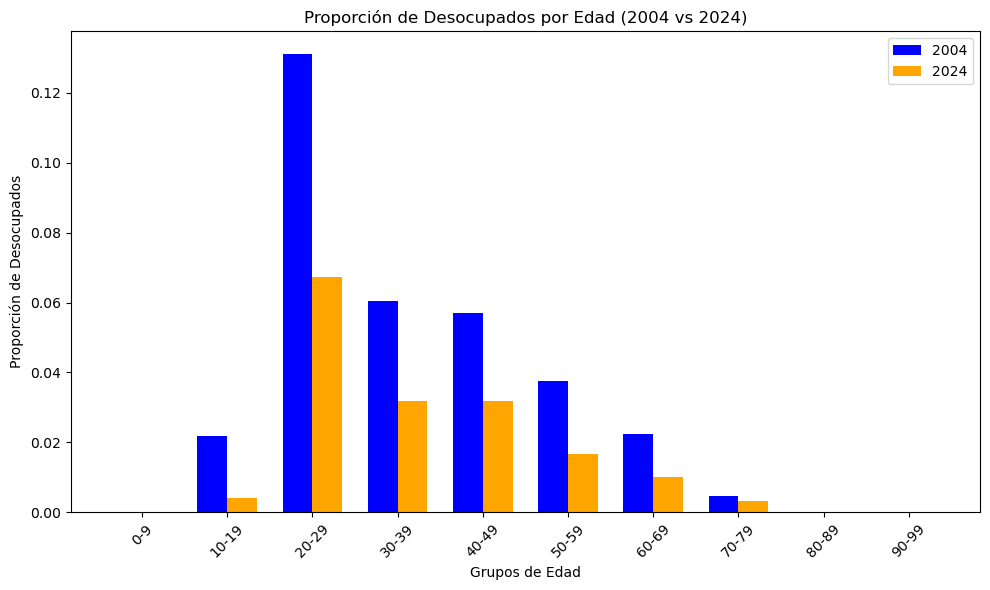

Grupo de edad 0-9: Cambio en la proporción de desocupados = 0.00
Grupo de edad 10-19: Cambio en la proporción de desocupados = -0.02
Grupo de edad 20-29: Cambio en la proporción de desocupados = -0.06
Grupo de edad 30-39: Cambio en la proporción de desocupados = -0.03
Grupo de edad 40-49: Cambio en la proporción de desocupados = -0.03
Grupo de edad 50-59: Cambio en la proporción de desocupados = -0.02
Grupo de edad 60-69: Cambio en la proporción de desocupados = -0.01
Grupo de edad 70-79: Cambio en la proporción de desocupados = -0.00
Grupo de edad 80-89: Cambio en la proporción de desocupados = 0.00
Grupo de edad 90-99: Cambio en la proporción de desocupados = 0.00


In [84]:
import matplotlib.pyplot as plt

# Agrupar edades en intervalos de 10 años para 2004
respondieron_2004['edad_grupo'] = pd.cut(respondieron_2004['CH06'], bins=range(0, 101, 10), right=False, labels=[f"{i}-{i+9}" for i in range(0, 100, 10)])

# Agrupar edades en intervalos de 10 años para 2024
respondieron_2024['edad_grupo'] = pd.cut(respondieron_2024['CH06'], bins=range(0, 101, 10), right=False, labels=[f"{i}-{i+9}" for i in range(0, 100, 10)])

# Calcular la proporción de desocupados por grupo de edad para 2004
proporc_desocupados_2004 = respondieron_2004.groupby('edad_grupo', observed=False)['Desocupado'].mean()

# Calcular la proporción de desocupados por grupo de edad para 2024
proporc_desocupados_2024 = respondieron_2024.groupby('edad_grupo', observed=False)['Desocupado'].mean()

# Unificar los índices por si hay diferencias en los grupos de edad entre 2004 y 2024
grupos_edad = sorted(set(proporc_desocupados_2004.index).union(set(proporc_desocupados_2024.index)))

# Valores en el mismo orden
val_2004 = [proporc_desocupados_2004.get(grupo, 0) for grupo in grupos_edad]
val_2024 = [proporc_desocupados_2024.get(grupo, 0) for grupo in grupos_edad]

# Crear gráfico de barras para comparar las proporciones de desocupados por edad entre 2004 y 2024
plt.figure(figsize=(10,6))
width = 0.35  # ancho de las barras
x = range(len(grupos_edad))

# Barras para 2004 y 2024
plt.bar(x, val_2004, width=width, label='2004', color='blue')
plt.bar([i + width for i in x], val_2024, width=width, label='2024', color='orange')

# Personalización del gráfico
plt.xlabel('Grupos de Edad')
plt.ylabel('Proporción de Desocupados')
plt.title('Proporción de Desocupados por Edad (2004 vs 2024)')
plt.xticks([i + width / 2 for i in x], grupos_edad, rotation=45)
plt.legend()

# Mostrar gráfico
plt.tight_layout()
plt.show()

# Comparar los cambios en la proporción de desocupados por edad
diferencias_edad = {grupo: val_2024[i] - val_2004[i] for i, grupo in enumerate(grupos_edad)}

# Mostrar las diferencias
for grupo, diferencia in diferencias_edad.items():
    print(f"Grupo de edad {grupo}: Cambio en la proporción de desocupados = {diferencia:.2f}")

In [86]:
# Verificar las columnas disponibles en 2004 y 2024
print(respondieron_2004.columns)
print(respondieron_2024.columns)

Index(['CODUSU', 'nro_hogar', 'componente', 'h15', 'ano4', 'trimestre',
       'region', 'mas_500', 'aglomerado', 'pondera',
       ...
       'adeccfr', 'pj1_1', 'pj2_1', 'pj3_1', 'idimpp', 'año', 'PEA', 'PET',
       'Desocupado', 'edad_grupo'],
      dtype='object', length=181)
Index(['CODUSU', 'ANO4', 'TRIMESTRE', 'NRO_HOGAR', 'COMPONENTE', 'H15',
       'REGION', 'MAS_500', 'AGLOMERADO', 'PONDERA',
       ...
       'RDECCFR', 'GDECCFR', 'PDECCFR', 'ADECCFR', 'PONDIH', 'año', 'PEA',
       'PET', 'Desocupado', 'edad_grupo'],
      dtype='object', length=182)


In [88]:
print("2004:", [col for col in respondieron_2004.columns if 'reg' in col.lower()])
print("2024:", [col for col in respondieron_2024.columns if 'reg' in col.lower()])

2004: ['region']
2024: ['REGION']


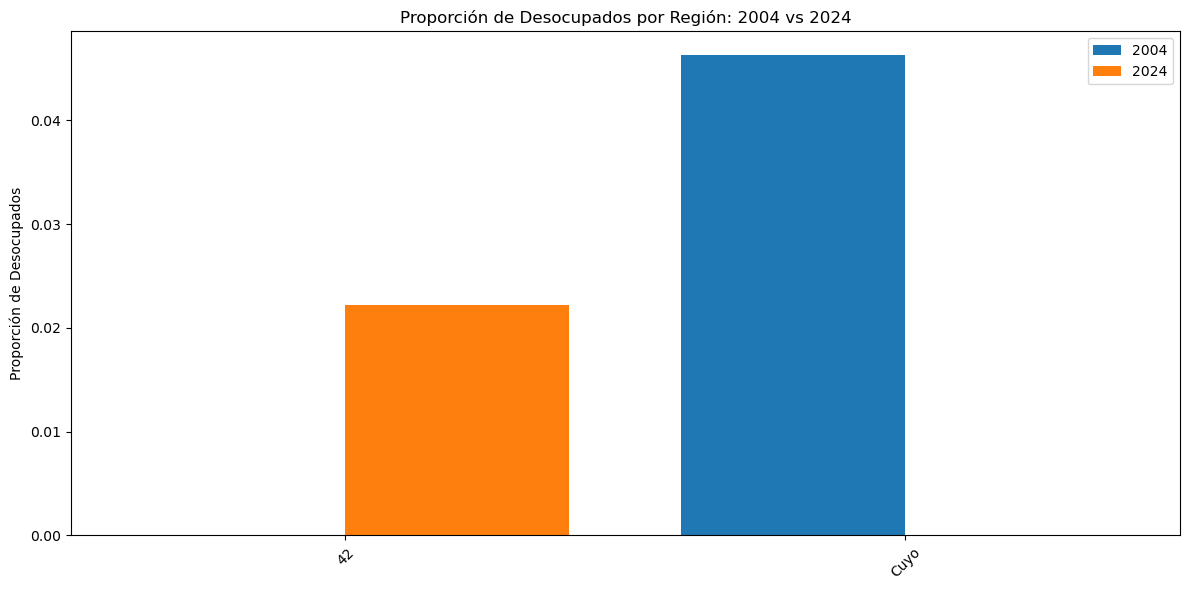

In [90]:
import pandas as pd
import matplotlib.pyplot as plt

# Asegurar que 'region' y 'REGION' estén en el mismo formato (string)
respondieron_2004['region'] = respondieron_2004['region'].astype(str)
respondieron_2024['REGION'] = respondieron_2024['REGION'].astype(str)

# Agrupar por región y calcular proporción de desocupados
desocupados_region_2004 = respondieron_2004.groupby('region', observed=True)['Desocupado'].mean()
desocupados_region_2024 = respondieron_2024.groupby('REGION', observed=True)['Desocupado'].mean()

# Renombrar índices como string para evitar errores
index_2004 = desocupados_region_2004.rename(index=lambda x: str(x))
index_2024 = desocupados_region_2024.rename(index=lambda x: str(x))

# Unificar los índices de ambas series
regiones = sorted(set(index_2004.index).union(set(index_2024.index)))

# Obtener proporciones en el mismo orden
val_2004 = [index_2004.get(region, 0) for region in regiones]
val_2024 = [index_2024.get(region, 0) for region in regiones]

# Crear gráfico comparativo
x = range(len(regiones))
plt.figure(figsize=(12,6))
plt.bar(x, val_2004, width=0.4, label='2004', align='center')
plt.bar([i + 0.4 for i in x], val_2024, width=0.4, label='2024', align='center')
plt.xticks([i + 0.2 for i in x], regiones, rotation=45)
plt.ylabel('Proporción de Desocupados')
plt.title('Proporción de Desocupados por Región: 2004 vs 2024')
plt.legend()
plt.tight_layout()
plt.show()

In [92]:
# Crear un DataFrame para visualizar la comparación de desocupados por región
df_comparacion_region = pd.DataFrame({
    'Region': regiones,
    'Desocupados 2004': val_2004,
    'Desocupados 2024': val_2024
})

# Mostrar el DataFrame
df_comparacion_region

,Region,Desocupados 2004,Desocupados 2024
0,42,0.000000,0.022188
1,Cuyo,0.046256,0.000000
